Q1)->Traditional MapReduce Writes intermediate results to disk after every map and reduce phase, making it slow ,while Apache Spark uses In-memory processing stores data in RAM whenever possible, significantly improving performance.

->Slow for iterative algorithms: some algorithms require multiple passes over the same data, causing repeated disk I/O and spark Reuses data in memory across iterations, making iterative workloads much faster.

Q2)
In traditional MapReduce, after each Map and Reduce phase, intermediate results are written to the hard disk. If an algorithm needs multiple iterations,every iteration must:

Read data from disk.
Process it.
Write the updated results back to disk.

This repeated disk I/O becomes the major performance bottleneck.
ex)Iteration 1: Disk → CPU → Disk
Iteration 2: Disk → CPU → Disk
Iteration 3: Disk → CPU → Disk
...
while Spark loads data into RAM (memory) and keeps it there across multiple operations. Frequently used datasets can be cached or persisted, so later iterations reuse the in-memory data instead of reading from disk again.
ex)Load once: Disk → Memory

Iteration 1: Memory → CPU
Iteration 2: Memory → CPU
Iteration 3: Memory → CPU
...
Save final result: Memory → Disk

In [5]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *

In [6]:
spark=SparkSession.builder \
      .appName("sales_dataset") \
      .getOrCreate()

In [7]:
df=spark.read.option('header','true').csv("Sales_dataset_t.csv",inferSchema=True)

In [8]:
df.show(5)

+-------+----------------+------+----------------+-----------+-------------+---+------------+---------+------+-----------------+--------+--------+-------------------+
|user_id|transaction_date|region|product_category|sale_amount|         city|age|subscription|   status| price|            email|username|store_id|      raw_timestamp|
+-------+----------------+------+----------------+-----------+-------------+---+------------+---------+------+-----------------+--------+--------+-------------------+
|     36|       3/23/2025|  East|        Clothing|     156.75|  Los Angeles| 37|     Premium|     NULL| 64.55|user1@example.com|   user1|     104|2025-03-23 00:00:00|
|     28|        1/5/2025|  East|     Electronics|     570.02|       Denver| 29|     Premium|  Pending|  24.6|user2@example.com|   user2|     103|2025-01-05 00:00:00|
|     21|       4/14/2025| South|       Groceries|     292.31|San Francisco| 40|       Basic|Completed|435.96|user3@example.com|   user3|     101|2025-04-14 00:00:00

In [9]:
df.printSchema()

root
 |-- user_id: integer (nullable = true)
 |-- transaction_date: string (nullable = true)
 |-- region: string (nullable = true)
 |-- product_category: string (nullable = true)
 |-- sale_amount: double (nullable = true)
 |-- city: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- subscription: string (nullable = true)
 |-- status: string (nullable = true)
 |-- price: double (nullable = true)
 |-- email: string (nullable = true)
 |-- username: string (nullable = true)
 |-- store_id: integer (nullable = true)
 |-- raw_timestamp: timestamp (nullable = true)



In [10]:
df.columns

['user_id',
 'transaction_date',
 'region',
 'product_category',
 'sale_amount',
 'city',
 'age',
 'subscription',
 'status',
 'price',
 'email',
 'username',
 'store_id',
 'raw_timestamp']

In [11]:
df.dtypes

[('user_id', 'int'),
 ('transaction_date', 'string'),
 ('region', 'string'),
 ('product_category', 'string'),
 ('sale_amount', 'double'),
 ('city', 'string'),
 ('age', 'int'),
 ('subscription', 'string'),
 ('status', 'string'),
 ('price', 'double'),
 ('email', 'string'),
 ('username', 'string'),
 ('store_id', 'int'),
 ('raw_timestamp', 'timestamp')]

Q3: Write a code snippet to remove all duplicate rows from a DataFrame based on a specific set of columns: user_id and transaction_date.

In [12]:
df.count()

205

In [13]:
df_spark=df.dropDuplicates(
    ["user_id","transaction_date"]
)

In [14]:
df_spark.count()

197

# 8 rows had duplicate user_id + transaction_date combinations

Q4: Given a DataFrame df_sales, write a query to filter for rows where the region is 'West' and then group by product_category to find the average sale_amount.

In [15]:
df_sales=df
df_sales.filter(df_sales.region=="West") \
.groupBy("product_category") \
.agg(avg("sale_amount").alias("average_sale")).show()


+----------------+-----------------+
|product_category|     average_sale|
+----------------+-----------------+
|       Groceries|           464.21|
|     Electronics|          393.294|
|        Clothing|441.7446153846153|
|       Furniture|          410.976|
+----------------+-----------------+



Q5: What is the difference between .na.drop() and .na.fill()? Provide a code example of filling null values in a status column with the string 'Unknown'.


**.na.drop():** Removes rows that contain NULL values. It is useful when missing data is invalid or cannot be used for analysis.
Multiple options are there like

'all':drops only if all columns are null

'any':drops if any column contains null value

Thresh can be used too to specify how many columns must be null to drop the record

**.na.fill():** Replaces NULL values with a specified value instead of deleting the rows. It helps preserve data while handling missing values.

In [16]:
df=df.na.fill({"status":"Unknown"})
df.show()

+-------+----------------+------+----------------+-----------+-------------+---+------------+---------+------+------------------+--------+--------+-------------------+
|user_id|transaction_date|region|product_category|sale_amount|         city|age|subscription|   status| price|             email|username|store_id|      raw_timestamp|
+-------+----------------+------+----------------+-----------+-------------+---+------------+---------+------+------------------+--------+--------+-------------------+
|     36|       3/23/2025|  East|        Clothing|     156.75|  Los Angeles| 37|     Premium|  Unknown| 64.55| user1@example.com|   user1|     104|2025-03-23 00:00:00|
|     28|        1/5/2025|  East|     Electronics|     570.02|       Denver| 29|     Premium|  Pending|  24.6| user2@example.com|   user2|     103|2025-01-05 00:00:00|
|     21|       4/14/2025| South|       Groceries|     292.31|San Francisco| 40|       Basic|Completed|435.96| user3@example.com|   user3|     101|2025-04-14 00

Q6: Write a query to find the total count of records for each city in a DataFrame, but only for cities where the count is greater than 100.


In [17]:
df.groupBy("city").count().filter("count>100").show()
# The dataset does not contain any city whose count is more that 100

+----+-----+
|city|count|
+----+-----+
+----+-----+



Q7: How does the immutability of Spark DataFrames affect how you perform "data cleaning" steps like dropping columns or renaming them?

Spark DataFrames are immutable, which means that once a DataFrame is created, it cannot be changed directly. Any operation such as dropping a column, renaming a column, filtering rows, or filling null values creates a new DataFrame instead of changing the original one.

Therefore, during data cleaning, you must assign the result of the operation to a new DataFrame or overwrite the existing variable.
This helps to restore the original dataframe as it is for future use

Q8: Write a Spark command to filter a dataset for rows where the age is between 18 and 30 (inclusive) and the subscription is 'Premium'.

In [18]:
df.filter(
    (df.age>=18) &
    (df.age<= 30) &
    (df.subscription=="Premium")).show()

+-------+----------------+------+----------------+-----------+-------------+---+------------+---------+------+-------------------+--------+--------+-------------------+
|user_id|transaction_date|region|product_category|sale_amount|         city|age|subscription|   status| price|              email|username|store_id|      raw_timestamp|
+-------+----------------+------+----------------+-----------+-------------+---+------------+---------+------+-------------------+--------+--------+-------------------+
|     28|        1/5/2025|  East|     Electronics|     570.02|       Denver| 29|     Premium|  Pending|  24.6|  user2@example.com|   user2|     103|2025-01-05 00:00:00|
|      8|       4/18/2025|  East|     Electronics|     808.94|      Phoenix| 24|     Premium|Completed|386.47|  user8@example.com|   user8|     103|2025-04-18 00:00:00|
|      8|        1/1/2025|  East|     Electronics|     907.31|      Seattle| 18|     Premium|  Pending| 44.79| user18@example.com|  user18|     104|2025-01

Q9: When cleaning a dataset, why is it often better to handle null values before performing mathematical aggregations like sum() or avg()?

Before performing mathematical operations like sum(), avg(), min(), or max(), it is important to handle null values because missing data can affect the accuracy and reliability of the results. If null values are left untreated, the calculations may not represent the actual state of the data and can lead to misleading conclusions.

For example, suppose a sales dataset contains the values 100, 200, NULL, and 300 in the price column. If the null value actually represents a missing sale amount that should be recorded as 0, then ignoring it may give an incorrect understanding of the total or average sales. On the other hand, if the row is incomplete and should not be considered at all, it is better to remove it before performing calculations.

Handling null values also helps avoid unexpected issues during data processing and ensures that all records are treated consistently. Depending on the situation, null values can either be filled with an appropriate value (such as 0, "Unknown", or the column average) or removed completely if they are not useful.

In Spark, methods like .na.fill() and .na.drop() are commonly used for this purpose. Cleaning the data first leads to more meaningful aggregations and improves the overall quality of the analysis.

Q10: Write the code to revise a column named raw_timestamp by casting it to a TimestampType and renaming it to event_time.

In [19]:
df=df.withColumnRenamed("raw_timestamp","event_time")
df=df.withColumn("event_time",col("event_time").cast(TimestampType()))


In [20]:
df.show()
df.printSchema()

+-------+----------------+------+----------------+-----------+-------------+---+------------+---------+------+------------------+--------+--------+-------------------+
|user_id|transaction_date|region|product_category|sale_amount|         city|age|subscription|   status| price|             email|username|store_id|         event_time|
+-------+----------------+------+----------------+-----------+-------------+---+------------+---------+------+------------------+--------+--------+-------------------+
|     36|       3/23/2025|  East|        Clothing|     156.75|  Los Angeles| 37|     Premium|  Unknown| 64.55| user1@example.com|   user1|     104|2025-03-23 00:00:00|
|     28|        1/5/2025|  East|     Electronics|     570.02|       Denver| 29|     Premium|  Pending|  24.6| user2@example.com|   user2|     103|2025-01-05 00:00:00|
|     21|       4/14/2025| South|       Groceries|     292.31|San Francisco| 40|       Basic|Completed|435.96| user3@example.com|   user3|     101|2025-04-14 00

Q11: Explain the "Shuffle" process that occurs during a grouping operation. Why is it considered a wide transformation?

In Apache Spark, shuffle is the process of redistributing data across different partitions or worker nodes similar to as of mapReduce concept where data is ditributed in many worker nodes and then combined the same nodes together from partitioned worker nodes so that records with the same key are brought together. This usually happens during operations such as groupBy(), join(), distinct().

For example, if we use groupBy("city"), the records for a particular city may initially be spread across multiple partitions. Before Spark can calculate the count or average for each city, it must move all rows belonging to the same city into the same partition. This movement of data between partitions is called shuffle.

Shuffle is considered a wide transformation because the output of one partition depends on data from multiple input partitions. Unlike narrow transformations (such as filter() or select()), where each output partition uses data from only one input partition, a wide transformation requires Spark to exchange data across the cluster. This data movement involves disk I/O and network communication, making the operation more expensive and slower hence unless it is very necessary to shuffle we should not use it.
ex)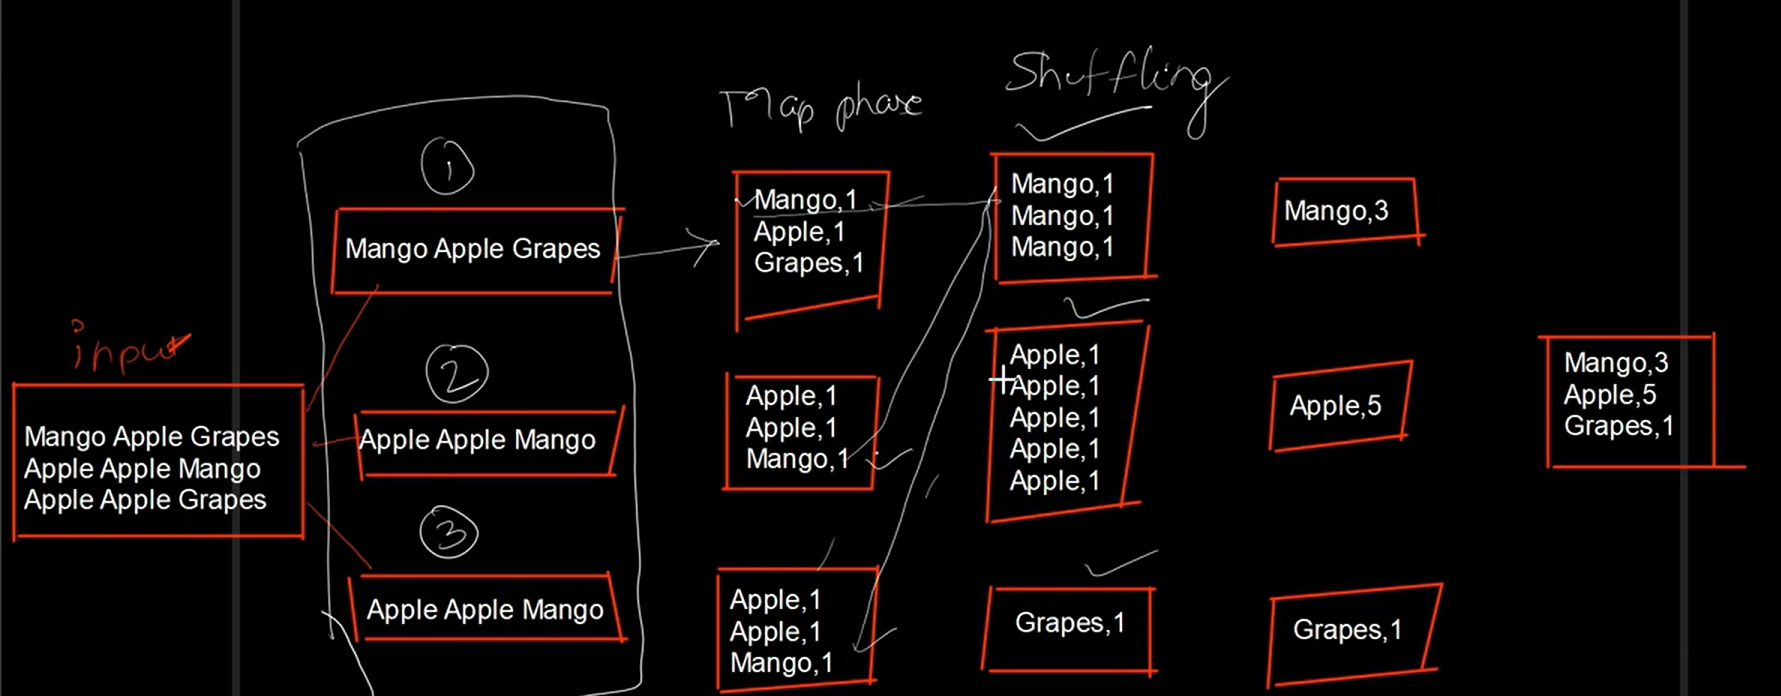

Q12: Write a code snippet that identifies and removes rows where the email column contains null values OR the username is an empty string.

In [21]:
df_null=df.filter(
    col("email").isNotNull() & (col("username")!="")
)
df_null.show()

+-------+----------------+------+----------------+-----------+-------------+---+------------+---------+------+------------------+--------+--------+-------------------+
|user_id|transaction_date|region|product_category|sale_amount|         city|age|subscription|   status| price|             email|username|store_id|         event_time|
+-------+----------------+------+----------------+-----------+-------------+---+------------+---------+------+------------------+--------+--------+-------------------+
|     36|       3/23/2025|  East|        Clothing|     156.75|  Los Angeles| 37|     Premium|  Unknown| 64.55| user1@example.com|   user1|     104|2025-03-23 00:00:00|
|     28|        1/5/2025|  East|     Electronics|     570.02|       Denver| 29|     Premium|  Pending|  24.6| user2@example.com|   user2|     103|2025-01-05 00:00:00|
|     21|       4/14/2025| South|       Groceries|     292.31|San Francisco| 40|       Basic|Completed|435.96| user3@example.com|   user3|     101|2025-04-14 00

Q13: How do you use the .agg() function to calculate multiple statistics at once, such as the min, max, and mean of the price column?


The .agg() function in PySpark is used to compute one or more aggregate statistics on a DataFrame. By passing functions like min(), max(), and mean(), we can calculate the minimum, maximum, and average values of the price column in a single operation.

In [22]:
df.agg(min("price").alias("min_price"),
       max("price").alias("max_Price"),
       mean("price").alias("average_price")).show()

+---------+---------+-----------------+
|min_price|max_Price|    average_price|
+---------+---------+-----------------+
|     19.5|   497.37|263.0326288659794|
+---------+---------+-----------------+



Q14: In the context of cleaning a dataset, what is the risk of using inferSchema=true when your source data contains messy or inconsistent date formats?

without inferSchema=True spark detects all column in string datatype, When inferSchema=true is used in Spark, it automatically detects the data type of each column by examining the values in the dataset. While this is convenient, it can cause problems if the date column contains inconsistent or messy formats.
For example, suppose a dataset contains the following values in the same date column:
23-03-2025
june 21, 2026

Since these values follow different formats, Spark may not be able to identify the correct data type. As a result, it may infer the column as a StringType instead of a TimestampType, or it may produce parsing errors and convert some values to NULL

This can create issues during data cleaning and analysis because operations such as sorting by date, filtering records within a date range, or calculating time differences may not work correctly. In some cases, incorrect schema inference can even lead to runtime errors when casting the column to a timestamp.

A better approach is to define the schema manually or first clean and standardize the date values so that all records follow the same format before loading them into Spark

Example:
If one row contains 2025-03-23 00:00:00 and another contains 3/23/2025 0:00, using inferSchema=true may not correctly recognize both as timestamps. Converting all dates to a single format like YYYY-MM-DD HH:MM:SS before processing makes the data more consistent and avoids such issues.

Q15: Write a final processing pipeline that:

Filters out duplicates.

Fills null prices with 0.

Groups by store_id to calculate total revenue.

I used my own sales dataset (`Sales_dataset_t.csv`) which has 205 rows and 14 columns including fields like `store_id`, `price`, `sale_amount`, `region`, `email`, etc. There were **5 duplicate rows** and **11 null values in the price column**, so this pipeline directly addresses real issues in the data.

In [54]:
from pyspark.sql.functions import sum

# Step 1: Remove duplicate rows
df_pipeline = df.dropDuplicates()

# Step 2: Fill null values in the price column with 0
df_pipeline = df_pipeline.na.fill({"price": 0})

# Step 3: Group by store_id and calculate total revenue
result = df_pipeline.groupBy("store_id").agg(
    sum("price").alias("total_revenue")
)


result.show()

+--------+------------------+
|store_id|     total_revenue|
+--------+------------------+
|     101|12631.970000000001|
|     103|          11976.08|
|     102|12096.319999999998|
|     104|          13423.43|
+--------+------------------+



In [55]:
result.toPandas().to_csv("revenue_by_store.csv", index=False)

#Brief Summary

->Learned pyspark basics and operations associated to dataset cleaning and transformation.

->I Successfully created a Spark Session and loaded the sales dataset into a PySpark DataFrame.

->Explored the dataset using show(), printSchema(), columns, and describe() to understand its structure and data types.

->Studied the limitations of MapReduce and understood why Apache Spark is preferred due to its in-memory processing and faster execution.

->Performed data cleaning by identifying and removing duplicate records using dropDuplicates().

->Handled missing values using .na.drop() and .na.fill(), including replacing null values in the status column with "Unknown" and filling null price values with 0.

->Applied various filtering operations, such as selecting records based on region, age range.

->Modified the dataset schema by renaming columns and casting raw_timestamp to TimestampType.
Used aggregation functions like count(), sum(), avg(), min(), and max() to summarize the data.

->Grouped records using groupBy() to calculate statistics such as average sales by product category and total revenue by store.

->Understood the concepts of Spark DataFrame immutability, shuffle operations, and wide transformations.
Removed invalid records where the email was null or the username was empty to improve data quality.

->Built a complete data processing pipeline that removed duplicates, filled missing prices, grouped data by store_id, and calculated the total revenue for each store.

->Saved the processed output for further analysis and submission named revenue_by_store.
